# CUPED vs Stratification: какой метод когда использовать? 

Статья: https://habr.com/ru/companies/X5Tech/articles/826488/

- **CUPED** работает очень точно, и иногда даже стратификация не нужна, так как он ее учитывает
- Если в какой-то страте есть сильные изменения во время эксперимента, то у **стратификации** более высокая мощность, чем у CUPED 
- Можно использовать **Stratification + CUPED** и мощность будет высокая

> Идея: использовать k-means для распределения на страты

Можно построить ML модель, которая по метрике до эксперимента и страте предсказывает метрику эксперимента. Прогноз модели будет иметь большую корреляцию с метрикой, чем просто метрика до эксперимента. Взяв прогноз модели в качестве ковариаты и использовав CUPED, получим мощность как у CUPED со стратификацией.

In [5]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [10]:
# Генерирем данные для экспериментов
def generate_data(
    sample_size=1000,
    effect=0,
    min_base=1000,
    max_base=3000,
    delta_strat=300,
    noise_std=300,
):
    # выбирем страты произвольно для теста и контроля
    strat = np.random.randint(0, 3, sample_size*2)
    # базовое занчение метрики для каждого пользователя
    base = np.random.uniform(min_base, max_base, sample_size*2)
    # чем выше страта, тем больше значение метрики
    base_with_strat = base + strat ** 2 * delta_strat
    # добавляем шум до эксперимента и после эксперимента
    noises = np.random.normal(0, noise_std, (2, sample_size*2))
    group = np.hstack([np.zeros(sample_size), np.ones(sample_size)])
    df = pd.DataFrame({
        'group': group,
        'strat': strat,
        'metric': base_with_strat + noises[0] + effect * group,
        'metric_before': base_with_strat + noises[1],
    }).astype(int)
    return df

df = generate_data()
df

,group,strat,metric,metric_before
0,0,1,2501,1836
1,0,1,2470,2671
2,0,0,2395,1727
3,0,1,1328,1729
4,0,2,2733,2349
...,...,...,...,...
1995,1,0,1009,1186
1996,1,2,1943,2466
1997,1,2,3857,3347
1998,1,0,3000,2039


In [ ]:
# Посчитаем MDE 
# Так как у функции tt_solve_power не информации о дисперсии
# Она возвращает MDE / sigma

mde = tt_solve_power(
    effect_size=None,  # This is what we want to find
    nobs=1000,         # sample size per group
    alpha=0.05,        # Type I error
    power=1-0.2,         # 1 - beta (power)
    alternative='two-sided'
)

mde = mde * df['metric'].std()
print(f"MDE = {mde:.1f}")

MDE = 72.9


In [23]:
# Обычный ttest
def ttest(control_df, test_df, *args):
    pvalue = stats.ttest_ind(control_df['metric'], test_df['metric']).pvalue

    return pvalue

# Считаем theta
def calculate_theta(metric, covariate):

    theta = np.cov(metric, covariate)[0, 1] / np.var(covariate)

    return theta

# CUPED ttest
def ttest_cuped(control_df, test_df, *args):
    total_df = pd.concat([control_df, test_df])
    theta = calculate_theta(total_df['metric'], total_df['covariate'])

    control = control_df['metric'] - theta * control_df['covariate']
    test = test_df['metric'] - theta * test_df['covariate']

    pvalue = stats.ttest_ind(control, test).pvalue

    return pvalue

# Mean with Stratification
def get_stratified_mean(df, weights):
    strat_mean = df.groupby('strat')['metric'].mean()

    return (weights * strat_mean).sum()

# Variance with Stratification
def get_stratified_var(df, weights):
    strat_var = df.groupby('strat')['metric'].var()

    return (weights * strat_var).sum()

# Ttest with Stratification
def ttest_strat(a_df, b_df, weights):
    a_strat_mean = get_stratified_mean(a_df, weights)
    a_strat_var = get_stratified_var(a_df, weights)
    b_strat_mean = get_stratified_mean(b_df, weights)
    b_strat_var = get_stratified_var(b_df, weights)

    se = np.sqrt(b_strat_var / len(a_df) + a_strat_var / len(b_df))

    if se == 0 or np.isnan(se) or np.isinf(se):
        return 1 # No Variance = No effect

    t = (b_strat_mean - a_strat_mean) / se

    pvalue = 2 * min(stats.norm().cdf(t), 1 - stats.norm().cdf(t))

    return pvalue

# Ttest with CUPED and Stratification
def ttest_cuped_strat(control_df, test_df, weights):
    total_df = pd.concat([control_df, test_df])
    theta = calculate_theta(total_df['metric'], total_df['covariate'])

    control_df = control_df.copy()
    test_df = test_df.copy()

    control_df['metric'] = control_df['metric'] - theta * control_df['covariate']
    test_df['metric'] = test_df['metric'] - theta * test_df['covariate']

    pvalue = ttest_strat(control_df, test_df, weights)

    return pvalue

In [20]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

def show_part_positive_ci(dict_pvalues, alpha=0.05):
    """Выводит точечные оценки и доверительные интервалы доли прокрасившихся экспериментов."""
    for key, pvalues in dict_pvalues.items():
        values = np.array(pvalues) < alpha
        pe, std = np.mean(values), np.std(values)
        mean_std = std / len(values) ** 0.5
        left, right = pe - 1.96 * mean_std, pe + 1.96 * mean_std
        print(pe, std)
        print(f'{key:<16}: pe={pe:0.3f}, ci=[{left:0.3f}, {right:0.3f}]')

def describe_pvalues(dict_pvalues):
    """Выводит описание распределения pvalue."""
    show_part_positive_ci(dict_pvalues)
    plot_pvalue_distribution(dict_pvalues)

100%|██████████| 10000/10000 [00:29<00:00, 338.67it/s]


ttest A/B  : pe=0.270, ci=[0.261, 0.279]
cuped A/B  : pe=0.399, ci=[0.390, 0.409]
strat A/B  : pe=0.399, ci=[0.390, 0.409]
cuped_strat A/B: pe=0.399, ci=[0.390, 0.409]


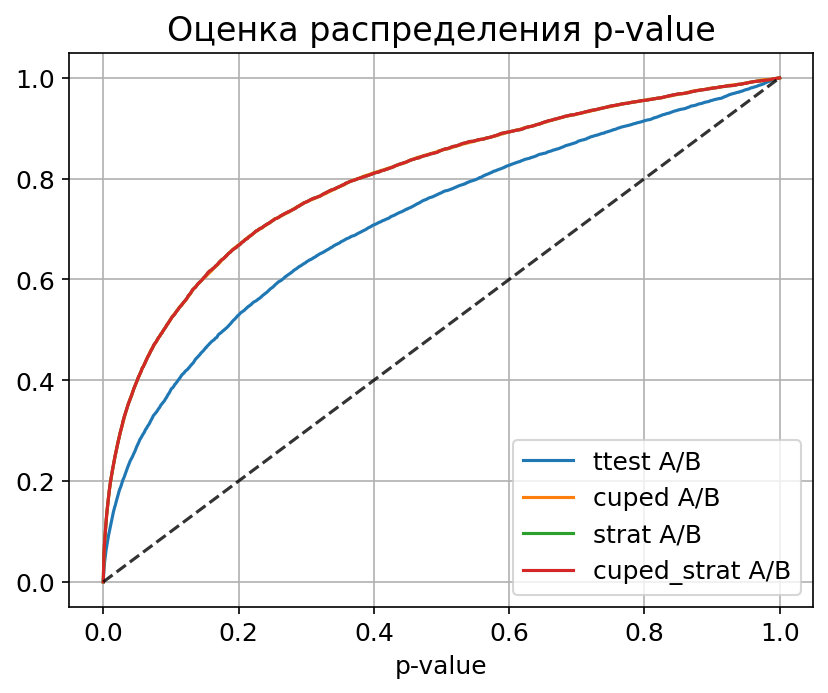

In [ ]:
# Кейс: знаем только страты. 
# Так как у нас ковариаты, то посчитаем ее как:
# среднее значение метрики на исторических данных по каждой страте

# Мощность у всех почти одинаковая

def generate_date_one(effect=0):
    df = generate_data(effect=effect)

    df_agg = pd.DataFrame(df.groupby('strat')['metric_before'].mean()).rename(columns={'metric_before': 'covariate'}).reset_index()

    df = df.merge(df_agg, on='strat')

    control, test = [df[df['group'] == group].copy() for group in [0, 1]]

    return control, test

dict_stattests = {
    'ttest': ttest,
    'cuped': ttest_cuped, 
    'strat': ttest_strat,
    'cuped_strat': ttest_cuped_strat
}

weights = pd.Series({0: 1/3, 1: 1/3, 2: 1/3})
effect = 50

dict_pvalues = defaultdict(list)

# Monte Carlo
n_iter = 10000
for _ in tqdm(range(n_iter)):
    a, b = generate_date_one(effect)
    for test_name, stattest in dict_stattests.items():
        pvalue = stattest(a, b, weights)
        dict_pvalues[test_name + " A/B"].append(pvalue)

describe_pvalues(dict_pvalues)

100%|██████████| 10000/10000 [00:17<00:00, 580.35it/s]


0.2749 0.4464638731185313
ttest A/B       : pe=0.275, ci=[0.266, 0.284]
0.7896 0.40759273791371703
cuped A/B       : pe=0.790, ci=[0.782, 0.798]
0.491 0.49991899343793683
strat_2 A/B     : pe=0.491, ci=[0.481, 0.501]
0.7198 0.4490968269760988
strat_5 A/B     : pe=0.720, ci=[0.711, 0.729]
0.7919 0.4059487529233216
strat_50 A/B    : pe=0.792, ci=[0.784, 0.800]
0.7813 0.4133646211276432
cuped_strat_50  : pe=0.781, ci=[0.773, 0.789]


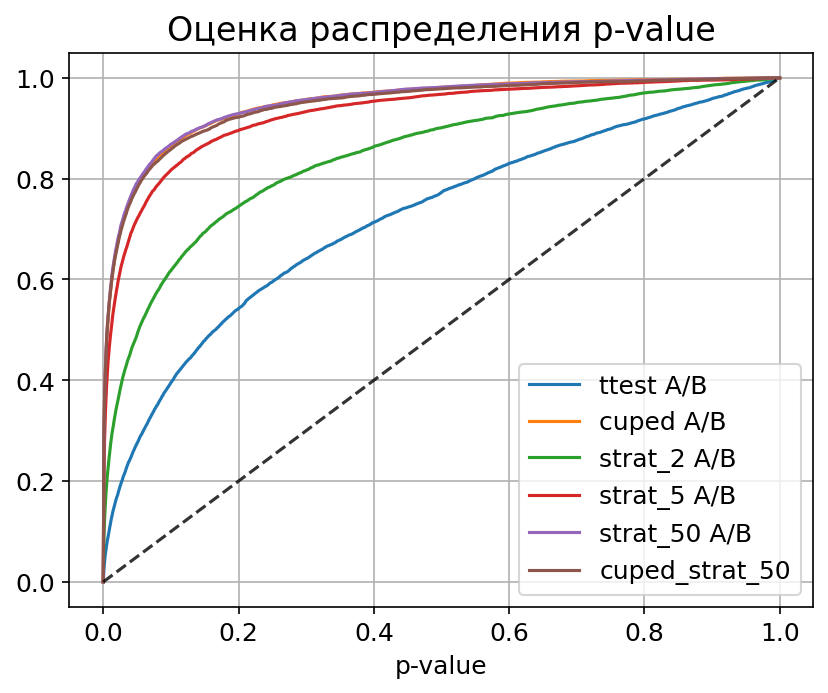

In [26]:
# Кейс: у нас есть готовая ковариата по историческим данным 
# Как распределить пользователей на страты?
# Посмотрим на квантили ковариаты и сделаем стратификацию так

def generate_data_two(effect, n_strat_array):
    df = generate_data(effect=effect)

    df['covariate'] = df['metric_before']

    df = df.sort_values('covariate')

    for n_strat in n_strat_array:
        df[f"strat_{n_strat}"] = np.arange(len(df)) // (len(df) // n_strat)

    control, test = [df[df['group'] == group].copy() for group in [0, 1]]

    return control, test

dict_stattests = {
    'ttest': ttest,
    'cuped': ttest_cuped, 
    'strat': ttest_strat,
}

n_strat_array = [2, 5, 50]

weights = pd.Series({0: 1/3, 1: 1/3, 2: 1/3})
effect = 50

dict_pvalues = defaultdict(list)

# Monte Carlo
n_iter = 10000
for _ in tqdm(range(n_iter)):
    a, b = generate_data_two(effect, n_strat_array)
    for test_name, stattest in dict_stattests.items():
        if test_name == 'strat':
            for n_strat in n_strat_array:
                a['strat'] = a[f"strat_{n_strat}"]
                b['strat'] = b[f"strat_{n_strat}"]
                weights = pd.Series({x: 1/n_strat for x in range(n_strat)})
                pvalue = stattest(a, b, weights)
                dict_pvalues[f"strat_{n_strat} A/B"].append(pvalue)
        else:
            pvalue = stattest(a, b)
            dict_pvalues[test_name + " A/B"].append(pvalue)

for _ in tqdm(range(n_iter)):
    a, b = generate_data_two(effect, n_strat_array)
    n_strat = 50
    a['strat'] = a[f"strat_{n_strat}"]
    b['strat'] = b[f"strat_{n_strat}"]
    weights = pd.Series({x: 1/n_strat for x in range(n_strat)})
    pvalue = ttest_cuped_strat(a, b, weights)
    dict_pvalues[f"cuped_strat_{n_strat}"].append(pvalue)

describe_pvalues(dict_pvalues)

100%|██████████| 10000/10000 [00:14<00:00, 687.16it/s]


0.2749 0.4464638731185313
ttest A/B       : pe=0.275, ci=[0.266, 0.284]
0.7896 0.40759273791371703
cuped A/B       : pe=0.790, ci=[0.782, 0.798]
0.491 0.49991899343793683
strat_2 A/B     : pe=0.491, ci=[0.481, 0.501]
0.7198 0.4490968269760988
strat_5 A/B     : pe=0.720, ci=[0.711, 0.729]
0.7919 0.4059487529233216
strat_50 A/B    : pe=0.792, ci=[0.784, 0.800]
0.7836 0.4117900435901772
cuped_strat_50  : pe=0.784, ci=[0.778, 0.789]


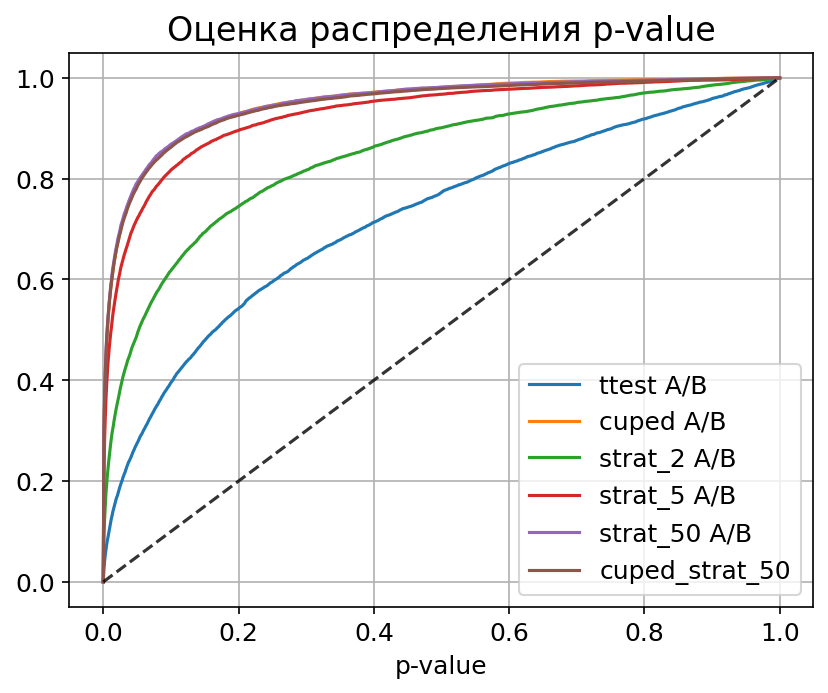

In [27]:
# Run the same using CUPED with Stratification

for _ in tqdm(range(n_iter)):
    a, b = generate_data_two(effect, n_strat_array)
    n_strat = 50
    a['strat'] = a[f"strat_{n_strat}"]
    b['strat'] = b[f"strat_{n_strat}"]
    weights = pd.Series({x: 1/n_strat for x in range(n_strat)})
    pvalue = ttest_strat(a, b, weights)
    dict_pvalues[f"cuped_strat_{n_strat}"].append(pvalue)

describe_pvalues(dict_pvalues)

100%|██████████| 10000/10000 [00:25<00:00, 392.14it/s]


0.2686 0.4432313617062764
ttest A/B       : pe=0.269, ci=[0.260, 0.277]
0.7777 0.415791666583158
cuped A/B       : pe=0.778, ci=[0.770, 0.786]
0.4006 0.4900200404065123
strat A/B       : pe=0.401, ci=[0.391, 0.410]
0.7875 0.4090767042988393
cuped_strat A/B : pe=0.787, ci=[0.779, 0.796]


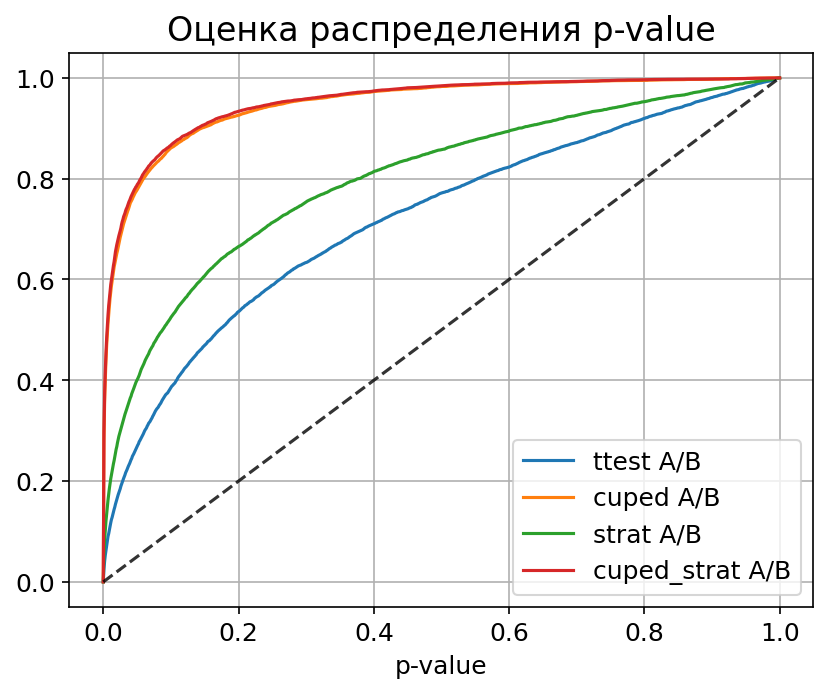

In [ ]:
# Кейс 3: теперь у нас есть и ковариата, и стратификация

# Видно, что CUPED уже учитывает стратификацию, 
# так как значения ковариант для разных страт разные
# Поэтому само использование стратификации дает небольшой прирост

def generate_data_three(effect=0):
    df = generate_data(effect=effect)
    df['covariate'] = df['metric_before']
    
    control, test = [df[df['group'] == group].copy() for group in [0, 1]]

    return control, test

dict_stattests = {
    'ttest': ttest,
    'cuped': ttest_cuped, 
    'strat': ttest_strat,
    'cuped_strat': ttest_cuped_strat
}

weights = pd.Series({0: 1/3, 1: 1/3, 2: 1/3})
effect = 50

dict_pvalues = defaultdict(list)

# Monte Carlo
n_iter = 10000
for _ in tqdm(range(n_iter)):
    a, b = generate_data_three(effect)
    for test_name, stattest in dict_stattests.items():
        pvalue = stattest(a, b, weights)
        dict_pvalues[test_name + " A/B"].append(pvalue)

describe_pvalues(dict_pvalues)

100%|██████████| 10000/10000 [00:27<00:00, 367.56it/s]


0.2027 0.40201083318736575
ttest A/B       : pe=0.203, ci=[0.195, 0.211]
0.2892 0.45339095712199645
cuped A/B       : pe=0.289, ci=[0.280, 0.298]
0.4033 0.4905599963307241
strat A/B       : pe=0.403, ci=[0.394, 0.413]
0.7898 0.4074505614181922
cuped_strat A/B : pe=0.790, ci=[0.782, 0.798]


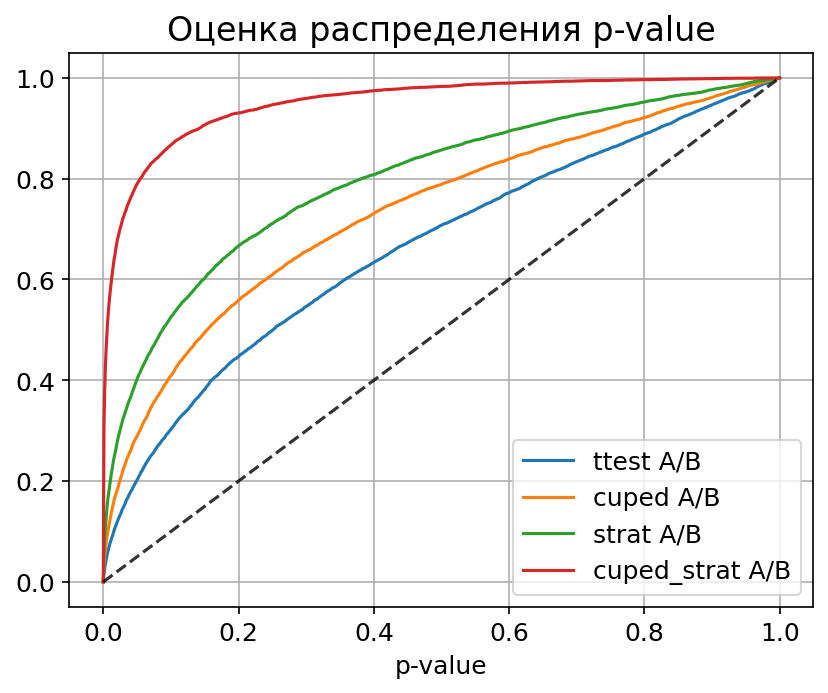

In [ ]:
# Кейс 4: пусть теперь страты это города, 
# и в одном городе резко увеличились продажи для тестовой и контрольной групп

# Видно, что при таких изменения у стратификации выше мощность, чем у обычного CUPED

def generate_data_four(effect=0, strat_effect=1500):
    df = generate_data(effect=effect)
    df['covariate'] = df['metric_before']

    df['metric'] += (df['strat'] == 1) * strat_effect

    control, test = [df[df['group'] == group].copy() for group in [0, 1]]

    return control, test

dict_stattests = {
    'ttest': ttest,
    'cuped': ttest_cuped, 
    'strat': ttest_strat,
    'cuped_strat': ttest_cuped_strat
}

weights = pd.Series({0: 1/3, 1: 1/3, 2: 1/3})
effect = 50

dict_pvalues = defaultdict(list)

# Monte Carlo
n_iter = 10000
for _ in tqdm(range(n_iter)):
    a, b = generate_data_four(effect)
    for test_name, stattest in dict_stattests.items():
        pvalue = stattest(a, b, weights)
        dict_pvalues[test_name + " A/B"].append(pvalue)

describe_pvalues(dict_pvalues)